In [1]:
!pip install sentence-transformers faiss-cpu networkx transformers

In [4]:
import numpy as np
import pandas as pd
import faiss
import pickle
import networkx as nx
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM  # Changed: pipeline is weak
import torch

final_df = pd.read_pickle("rag_data.pkl")
embeddings = np.load("embeddings.npy")
index = faiss.read_index("faiss_index.idx")

with open("kg_final.pkl", "rb") as f:
    G = pickle.load(f)

with open("centroids.pkl", "rb") as f:
    cluster_centroids = pickle.load(f)


In [5]:
# Embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")  # Renamed for clarity

# Reranker
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")  # snake_case

# Generator - Use LARGE not BASE (base is too weak)
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")
generator = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-large",
    torch_dtype=torch.float16,  # Saves memory
    device_map="auto"  # Uses GPU if available
)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9168.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 11014.18it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
Loa

In [6]:
rewrite_cache = {}  # Renamed for clarity

def rewrite_query(query):
    """Rewrite query to standard English - with caching"""
    
    if query in rewrite_cache:
        return rewrite_cache[query]
    
    prompt = f"Rewrite this agricultural query in clear English: {query}"
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(generator.device) for k, v in inputs.items()}  # Move to GPU
    
    with torch.no_grad():  # Saves memory
        outputs = generator.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False
        )
    
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    rewrite_cache[query] = result
    
    return result


In [7]:
def embed(query):
    """Embed a query using the sentence transformer"""
    return embed_model.encode([query], normalize_embeddings=True)


In [8]:
def faiss_retrieve(query, k=10):  # Increased default k for better recall
    """Retrieve top-k similar queries from FAISS index"""
    q_emb = embed(query)
    distances, indices = index.search(q_emb, k)
    
    results = final_df.iloc[indices[0]].copy()
    results["similarity_score"] = distances[0]  # Keep scores for debugging
    
    return results


In [9]:
def is_hinglish(query):
    """Check if query contains Hinglish/Hindi words"""
    hindi_markers = ["hai", "ka", "ki", "kya", "kaise", "ilaj", "kare", 
                     "mein", "ke", "liye", "ho", "raha", "rahi", "hain", "karo"]
    query_words = query.lower().split()
    return any(word in query_words for word in hindi_markers)


In [10]:
def kg_retrieve(query, cluster_centroids, top_k=5):
    """Retrieve answers from knowledge graph via cluster matching"""
    
    q_emb = embed(query).flatten()
    
    best_cluster = None
    best_sim = -1
    
    for cluster_id, centroid in cluster_centroids.items():
        centroid = np.array(centroid).flatten()
        sim = np.dot(q_emb, centroid)
        
        if np.isnan(sim):
            continue
        if sim > best_sim:
            best_sim = sim
            best_cluster = cluster_id
    
    if best_cluster is None:
        return []
    
    cluster_node = f"cluster_{best_cluster}"
    
    if cluster_node not in G:  # FIXED: was 'node'
        return []
    
    answers = []
    for neighbor in G.neighbors(cluster_node):
        node_data = G.nodes.get(neighbor, {})
        if node_data.get("type") == "answer":
            answers.append(neighbor)
    
    return answers[:top_k]  # ADDED: limit results


In [11]:
def merge_results(faiss_df, kg_results):  # Fixed typo: fauss -> faiss
    """Merge and deduplicate results from FAISS and KG"""
    
    faiss_answers = faiss_df["clean_answer"].tolist()
    
    combined = []
    seen = set()
    
    # Interleave: FAISS, KG, FAISS, KG, ...
    for i in range(max(len(faiss_answers), len(kg_results))):
        if i < len(faiss_answers):
            ans = faiss_answers[i]
            normalized = " ".join(ans.lower().split())
            if normalized not in seen and isinstance(ans, str) and ans.strip():
                seen.add(normalized)
                combined.append(ans)
        
        if i < len(kg_results):
            ans = kg_results[i]
            normalized = " ".join(ans.lower().split())
            if normalized not in seen and isinstance(ans, str) and ans.strip():
                seen.add(normalized)
                combined.append(ans)
    
    return combined


In [12]:
def rerank(query, candidates, k=5):
    """Rerank candidates using cross-encoder"""
    
    if not candidates:
        return []
    
    # Filter invalid candidates
    valid_candidates = [c for c in candidates if isinstance(c, str) and c.strip()]
    
    if not valid_candidates:
        return []
    
    pairs = [(query, c) for c in valid_candidates]
    scores = cross_encoder.predict(pairs)  # Fixed: crossEncoder -> cross_encoder
    
    ranked = sorted(zip(valid_candidates, scores), key=lambda x: x[1], reverse=True)
    
    return [item[0] for item in ranked[:k]]


In [13]:
import re

def preprocess_context(answers):
    """Clean and normalize retrieved answers"""
    
    # Word-level corrections (use word boundaries)
    corrections = {
        r'\blitre\b': 'liter',
        r'\bgm\b': 'gram',
        r'\bgms\b': 'grams',
        r'\bmlit\b': 'ml',
        r'\bspry\b': 'spray',
        r'\bspre\b': 'spray',
        r'\bwatar\b': 'water',
        r'\bmllit\b': 'ml per liter',
        r'\bgmlit\b': 'gram per liter',
    }
    
    cleaned = []
    for ans in answers:
        if not isinstance(ans, str):
            continue
            
        ans = ans.lower().strip()
        
        # Apply corrections with word boundaries
        for pattern, replacement in corrections.items():
            ans = re.sub(pattern, replacement, ans)
        
        # Keep alphanumeric, spaces, periods, slashes (for dosages like 2ml/liter)
        ans = re.sub(r"[^a-z0-9\s\./]", " ", ans)
        ans = re.sub(r'\s+', ' ', ans).strip()
        
        if len(ans) > 10:  # Skip very short answers
            cleaned.append(ans)
    
    return cleaned


In [103]:
def generate_answer(query, retrieved_answers):
    """
    Generate a coherent answer by synthesizing retrieved information.
    
    KEY FIXES:
    1. Better prompt structure for Flan-T5
    2. Explicit instructions to synthesize, not concatenate
    3. Handling edge cases
    4. Post-processing to clean output
    """
    
    # Handle empty results
    if not retrieved_answers:
        return "Sorry, I couldn't find relevant information for your query. Please provide more details about your crop, symptoms, or specific problem."
    
    # Preprocess answers
    cleaned_answers = preprocess_context(retrieved_answers)
    
    if not cleaned_answers:
        return "The retrieved information was not clear enough. Please try rephrasing your question."
    
    # Take top 5 most relevant (already reranked)
    top_answers = cleaned_answers[:5]
    
    # Detect language
    hinglish = is_hinglish(query)
    
    # Build context - numbered for clarity
    context_lines = [f"{i+1}. {ans}" for i, ans in enumerate(top_answers)]
    context = "\n".join(context_lines)
    
    # Language instruction
    lang_instruction = "Respond in simple Hinglish." if hinglish else "Respond in clear English."
    
    # BETTER PROMPT - More explicit instructions for Flan-T5
    prompt = f"""Task: You are an agricultural expert. Read the farmer's question and the retrieved information, then write a helpful answer.

Farmer's Question: {query}

Retrieved Information:
{context}

Instructions:
- Write ONE clear, practical answer related to same crop as mentioned(2-3 sentences)
- Include specific dosages and chemical names exactly as written
- Do not just copy the retrieved text, synthesize it with most practical solution




- {lang_instruction}

Expert Answer:"""

    # Tokenize with proper settings
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )
    
    # Move to GPU
    inputs = {k: v.to(generator.device) for k, v in inputs.items()}
    
    # Generate
    with torch.no_grad():
        outputs = generator.generate(
            **inputs,
            max_new_tokens=120,
            min_new_tokens=20,
            do_sample=False,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,  # Prevents repetition
            length_penalty=1.0,
        )
    
    # Decode
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Post-process
    result = post_process_answer(result, query)
    
    return result


def post_process_answer(answer, query):
    """Clean up generated answer"""
    
    answer = answer.strip()
    
    # Remove prompt leakage
    remove_prefixes = [
        "Expert Answer:",
        "Answer:",
        "Final Answer:",
        "Response:",
    ]
    for prefix in remove_prefixes:
        if answer.startswith(prefix):
            answer = answer[len(prefix):].strip()
    
    # If answer is too short or garbage, return fallback
    if len(answer) < 20:
        return "Please consult your local agricultural officer for specific recommendations on this issue."
    
    # If answer just repeats the query, it's bad
    if query.lower() in answer.lower() and len(answer) < 50:
        return "For this issue, spray recommended pesticide at proper dosage. Consult local agricultural officer for specific chemicals available in your area."
    
    # Capitalize first letter
    if answer and answer[0].islower():
        answer = answer[0].upper() + answer[1:]
    
    # Ensure ends with period
    if answer and answer[-1] not in '.!?':
        answer += '.'
    
    return answer


In [104]:
def run_pipeline(query, cluster_centroids, k=5, skip_rewrite=False):
    """
    Complete RAG+KG pipeline
    
    Args:
        query: User's question
        cluster_centroids: Precomputed cluster centroids
        k: Number of final answers to return
        skip_rewrite: Skip query rewriting (faster)
    """
    
    # Step 1: Query rewriting (optional - can skip for speed)
    if skip_rewrite:
        processed_query = query.lower().strip()
    else:
        processed_query = rewrite_query(query)
    
    # Step 2: FAISS retrieval (get more, filter later)
    faiss_results = faiss_retrieve(processed_query, k=15)
    
    # Step 3: KG retrieval
    kg_results = kg_retrieve(processed_query, cluster_centroids, top_k=10)
    
    # Step 4: Merge and deduplicate
    combined = merge_results(faiss_results, kg_results)
    
    # Step 5: Rerank
    if len(combined) > k:
        reranked = rerank(processed_query, combined, k=k)
    else:
        reranked = combined[:k]
    
    # Step 6: Generate answer
    generated_answer = generate_answer(query, reranked)  # Use ORIGINAL query for language
    
    return {
        "query": query,
        "processed_query": processed_query,
        "retrieved_answers": reranked,
        "generated_answer": generated_answer
    }


# Fast version for evaluation (skips slow rewriting)
def run_pipeline_fast(query, cluster_centroids, k=5):
    """Faster pipeline for evaluation - skips rewriting"""
    return run_pipeline(query, cluster_centroids, k=k, skip_rewrite=True)


In [105]:
output = run_pipeline("yellowing of leaf in paddy ", cluster_centroids)



In [106]:
print("\n🔹 Rewritten Query:")
print(output["processed_query"])

print("\n🔹 Retrieved Answers:")
print(output["retrieved_answers"])


print("\n🔹 Final Answer:")
print(output["generated_answer"])


🔹 Rewritten Query:
Yellowing of leaf in paddy

🔹 Retrieved Answers:
['yellow colour in paddydhan spray in copper oxichloride 2 gmwater', 'leaf yellow can be minimized by spraying 2 urea mixed with mancozeb at 25 gmlit', 'kisan bhai koi samasya hai nahi hai', 'use zinksulphate and urea', 'menkozeb 2 gmlit for spray']

🔹 Final Answer:
Use urea mixed with mancozeb at 25 gram per liter for yellowing of leaf in paddy.


In [107]:
output = run_pipeline(" there is excess water in field", cluster_centroids)

In [108]:
print("\n🔹 Rewritten Query:")
print(output["processed_query"])

print("\n🔹 Retrieved Answers:")
print(output["retrieved_answers"])


print("\n🔹 Final Answer:")
print(output["generated_answer"])


🔹 Rewritten Query:
there is excess water in the field

🔹 Retrieved Answers:
['drain out excess water from field', 'advised to remove excess water from rice field', 'wait till rainfallavoid excess dry in field', 'explain as per water requirment in that field', 'water quantity in rice field not needed during harvest stage']

🔹 Final Answer:
If there is excess water in the field, you need to remove excess water from the field. You can do this by draining the excess water out of the field with a garden hose.


In [111]:
output = run_pipeline("rice mai stem borer ka ilaj", cluster_centroids)

In [112]:
print("\n🔹 Rewritten Query:")
print(output["processed_query"])

print("\n🔹 Retrieved Answers:")
print(output["retrieved_answers"])


print("\n🔹 Final Answer:")
print(output["generated_answer"])


🔹 Rewritten Query:
stem borer in rice

🔹 Retrieved Answers:
['stem borer in rice crop spray chloropyriphos 5 milliliter per liter', 'rice stem borer in rice spray profenophos 2 mllit of water', 'stem borer borer in rice spray profenophos 2 mllit of water', 'stem borer in rice spray quinolphos 2 mlneemoil 3 mlteepol 1 mlit of water', 'stem borer in rice spray profenophos 2 mlneemoil teepol 1 mllit of water brinjal carbaryl 2 gmacephate 2 gmneemoil 3 mlteepol 1 mllit of water 19 19 19 10 gmlit of water']

🔹 Final Answer:
The best way to get rid of stem borer is to spray the crop with chloropyriphos.


In [46]:
import pandas as pd

test_df = pd.read_csv("test_data.csv")

In [48]:
test_df_eval = test_df[["clean_query", "clean_answer"]].copy()

test_df_eval.rename(columns={
    "clean_query": "query",
    "clean_answer": "ground_truth"
}, inplace=True)

In [49]:
test_df_eval = test_df_eval.dropna()

In [50]:
test_df_eval = test_df_eval.reset_index(drop=True)

In [51]:
print(test_df_eval.columns)
test_df_eval.head()
print("Size:", len(test_df_eval))

Index(['query', 'ground_truth'], dtype='object')
Size: 91310


In [56]:
from sentence_transformers import SentenceTransformer, util

# Load evaluation model once
eval_model = SentenceTransformer("intfloat/multilingual-e5-base")

def compute_relevance_score(retrieved_ans, ground_truth):
    """
    Compute a relevance score between retrieved answer and ground truth.
    Returns score between 0 and 1.
    """
    gt = ground_truth.lower().strip()
    ans = retrieved_ans.lower().strip()
    
    # Semantic similarity
    gt_emb = eval_model.encode(gt, convert_to_tensor=True)
    ans_emb = eval_model.encode(ans, convert_to_tensor=True)
    semantic_score = util.cos_sim(gt_emb, ans_emb).item()
    
    # Lexical overlap
    gt_words = set(gt.split())
    ans_words = set(ans.split())
    overlap = len(gt_words & ans_words) / max(len(gt_words), 1)
    
    # Number match (important for dosages)
    import re
    gt_numbers = set(re.findall(r'\d+(?:\.\d+)?', gt))
    ans_numbers = set(re.findall(r'\d+(?:\.\d+)?', ans))
    number_score = len(gt_numbers & ans_numbers) / max(len(gt_numbers), 1) if gt_numbers else 1.0
    
    # Combined score (weighted)
    final_score = 0.6 * semantic_score + 0.25 * overlap + 0.15 * number_score
    
    return final_score


def is_relevant(retrieved_ans, ground_truth, threshold=0.65):
    """Binary relevance check"""
    return compute_relevance_score(retrieved_ans, ground_truth) >= threshold


def hit_at_k(retrieved_list, ground_truth, k):
    """Hit@K: 1 if any of top-k is relevant, else 0"""
    for ans in retrieved_list[:k]:
        if is_relevant(ans, ground_truth):
            return 1
    return 0


def mrr(retrieved_list, ground_truth):
    """Mean Reciprocal Rank"""
    for i, ans in enumerate(retrieved_list):
        if is_relevant(ans, ground_truth):
            return 1.0 / (i + 1)
    return 0.0


def precision_at_k(retrieved_list, ground_truth, k):
    """Precision@K: fraction of top-k that are relevant"""
    relevant = sum(1 for ans in retrieved_list[:k] if is_relevant(ans, ground_truth))
    return relevant / k


def ndcg_at_k(retrieved_list, ground_truth, k):
    """NDCG@K with graded relevance"""
    from sklearn.metrics import ndcg_score
    
    scores = [compute_relevance_score(ans, ground_truth) for ans in retrieved_list[:k]]
    
    # Pad if needed
    while len(scores) < k:
        scores.append(0.0)
    
    # Ideal = sorted descending
    ideal = sorted(scores, reverse=True)
    
    if sum(ideal) == 0:
        return 0.0
    
    return ndcg_score([ideal], [scores])


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9169.24it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
def reciprocal_rank_semantic(retrieved, ground_truth):
    gt = ground_truth.lower().strip()
    gt_words = set(gt.split())

    gt_emb = eval_model.encode(gt, convert_to_tensor=True)

    for i, ans in enumerate(retrieved):
        ans = ans.lower().strip()
        ans_words = set(ans.split())

        ans_emb = eval_model.encode(ans, convert_to_tensor=True)
        score = util.cos_sim(gt_emb, ans_emb).item()

        overlap = len(gt_words & ans_words)

        numbers_gt = set([w for w in gt.split() if w.isdigit()])
        numbers_ans = set([w for w in ans.split() if w.isdigit()])
        number_match = len(numbers_gt & numbers_ans)

        # if (
        #     score >= 0.85 and
        #     overlap >= 3 and
        #     (len(numbers_gt) == 0 or number_match >= 1)
        # ):
        if (
            (score >= 0.85 and overlap >= 3 and (len(numbers_gt) == 0 or number_match >= 1)) or
            (score >= 0.70 and overlap >= 4)
        ):
            
            return 1 / (i + 1)

    return 0

In [58]:
sample_test = test_df_eval.sample(500, random_state=42)

In [60]:
from tqdm import tqdm
from collections import defaultdict

def evaluate_retrieval(test_df, cluster_centroids, sample_size=500, seed=42):
    """
    Comprehensive retrieval evaluation
    """
    
    # Sample test data
    np.random.seed(seed)
    if len(test_df) > sample_size:
        sample_df = test_df.sample(sample_size, random_state=seed)
    else:
        sample_df = test_df
    
    metrics = defaultdict(list)
    
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Evaluating"):
        query = row["query"]
        ground_truth = row["ground_truth"]
        
        # Run pipeline
        result = run_pipeline_fast(query, cluster_centroids, k=10)
        retrieved = result["retrieved_answers"]
        
        # Compute metrics at different k
        for k in [1, 3, 5, 10]:
            metrics[f"hit@{k}"].append(hit_at_k(retrieved, ground_truth, k))
            metrics[f"precision@{k}"].append(precision_at_k(retrieved, ground_truth, k))
            # metrics[f"ndcg@{k}"].append(ndcg_at_k(retrieved, ground_truth, k))
        
        metrics["mrr"].append(mrr(retrieved, ground_truth))
    
    # Aggregate
    results = {k: np.mean(v) for k, v in metrics.items()}
    
    # Print results
    print("\n" + "=" * 50)
    print("RETRIEVAL EVALUATION RESULTS")
    print("=" * 50)
    print(f"Sample size: {len(sample_df)}")
    print("-" * 50)
    
    for k in [1, 3, 5, 10]:
        print(f"\nK = {k}:")
        print(f"  Hit@{k}:       {results[f'hit@{k}']:.4f}")
        print(f"  Precision@{k}: {results[f'precision@{k}']:.4f}")
        # print(f"  NDCG@{k}:      {results[f'ndcg@{k}']:.4f}")
    
    print(f"\nMRR: {results['mrr']:.4f}")
    
    return results


# Run evaluation
test_df_eval = pd.read_csv("test_data.csv")
test_df_eval = test_df_eval[["clean_query", "clean_answer"]].dropna()
test_df_eval.columns = ["query", "ground_truth"]

results = evaluate_retrieval(test_df_eval, cluster_centroids, sample_size=500)


Evaluating:  55%|█████▌    | 277/500 [1:25:55<1:09:10, 18.61s/it]


AttributeError: 'float' object has no attribute 'lower'

In [113]:
!pip install rouge-score bert-score sacrebleu -q
from collections import defaultdict
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import sacrebleu
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_generation(test_df, cluster_centroids, sample_size=200, seed=42):
    np.random.seed(seed)
    sample_df = test_df.sample(min(sample_size, len(test_df)), random_state=seed)

    scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
    rouge_scores = defaultdict(list)
    generated, reference = [], []

    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Generating"):
        query, gt = row["query"], row["ground_truth"]
        res = run_pipeline(query, cluster_centroids, k=5, skip_rewrite=True)
        gen = res["generated_answer"]
        generated.append(gen)
        reference.append(gt)
        r = scorer.score(gt, gen)
        for k in ['rouge1','rouge2','rougeL']:
            rouge_scores[k].append(r[k].fmeasure)

    # ---- BLEU + BERT ----
    bleu = sacrebleu.corpus_bleu(generated, [reference])
    P, R, F1 = bert_score(generated, reference, lang="en", verbose=False)

    results = {
        'rouge1': np.mean(rouge_scores['rouge1']),
        'rouge2': np.mean(rouge_scores['rouge2']),
        'rougeL': np.mean(rouge_scores['rougeL']),
        'bert_precision': P.mean().item(),
        'bert_recall': R.mean().item(),
        'bert_f1': F1.mean().item(),
        'bleu': bleu.score / 100.0,
    }

    print("\n" + "="*50)
    print("GENERATION EVALUATION RESULTS")
    print("="*50)
    for k,v in results.items():
        print(f"{k.upper():15}: {v:.4f}")

    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    sns.barplot(y=list(results.keys()), x=list(results.values()), ax=ax[0])
    ax[0].set_title("Average Text Similarity Metrics")
    sns.histplot(F1.cpu(), bins=20, kde=True, ax=ax[1])
    ax[1].set_title("BERTScore F1 Distribution")
    plt.tight_layout()
    plt.show()

    return results


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [61]:
# # Install required packages
# !pip install rouge-score bert-score -q

# from rouge_score import rouge_scorer
# from bert_score import score as compute_bert_score

# def evaluate_generation(test_df, cluster_centroids, sample_size=200, seed=42):
#     """
#     Evaluate the quality of generated answers
#     """
    
#     np.random.seed(seed)
#     sample_df = test_df.sample(min(sample_size, len(test_df)), random_state=seed)
    
#     rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
#     generated_answers = []
#     reference_answers = []
    
#     rouge_scores = defaultdict(list)
    
#     for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Generating"):
#         query = row["query"]
#         ground_truth = row["ground_truth"]
        
#         result = run_pipeline(query, cluster_centroids, k=5, skip_rewrite=True)
#         generated = result["generated_answer"]
        
#         generated_answers.append(generated)
#         reference_answers.append(ground_truth)
        
#         # ROUGE scores
#         scores = rouge.score(ground_truth, generated)
#         rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
#         rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
#         rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)
    
#     # BERTScore (batch computation)
#     print("\nComputing BERTScore...")
#     P, R, F1 = compute_bert_score(
#         generated_answers, 
#         reference_answers, 
#         lang="en",
#         verbose=False
#     )
    
#     # Results
#     results = {
#         'rouge1': np.mean(rouge_scores['rouge1']),
#         'rouge2': np.mean(rouge_scores['rouge2']),
#         'rougeL': np.mean(rouge_scores['rougeL']),
#         'bert_precision': P.mean().item(),
#         'bert_recall': R.mean().item(),
#         'bert_f1': F1.mean().item(),
#     }
    
#     print("\n" + "=" * 50)
#     print("GENERATION EVALUATION RESULTS")
#     print("=" * 50)
#     print(f"Sample size: {len(sample_df)}")
#     print("-" * 50)
#     print(f"ROUGE-1: {results['rouge1']:.4f}")
#     print(f"ROUGE-2: {results['rouge2']:.4f}")
#     print(f"ROUGE-L: {results['rougeL']:.4f}")
#     print(f"BERTScore P: {results['bert_precision']:.4f}")
#     print(f"BERTScore R: {results['bert_recall']:.4f}")
#     print(f"BERTScore F1: {results['bert_f1']:.4f}")
    
#     return results

# # Run generation evaluation
# gen_results = evaluate_generation(test_df_eval, cluster_centroids, sample_size=200)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Generating: 100%|██████████| 200/200 [39:34<00:00, 11.87s/it]



Computing BERTScore...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10365.19it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



GENERATION EVALUATION RESULTS
Sample size: 200
--------------------------------------------------
ROUGE-1: 0.1458
ROUGE-2: 0.0553
ROUGE-L: 0.1299
BERTScore P: 0.8339
BERTScore R: 0.8007
BERTScore F1: 0.8165


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8750.36it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



GENERATION EVALUATION RESULTS
ROUGE1         : 0.2151
ROUGE2         : 0.0861
ROUGEL         : 0.1843
BERT_PRECISION : 0.8350
BERT_RECALL    : 0.8245
BERT_F1        : 0.8294
BLEU           : 0.0685


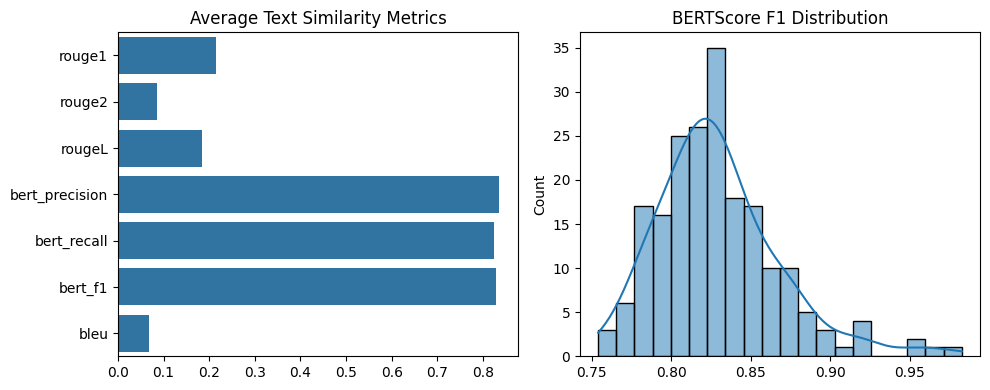

In [114]:
gen_results = evaluate_generation(test_df_eval, cluster_centroids, sample_size=200)